In [1]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

ModuleNotFoundError: No module named 'datasets'

# LLM

Использование LLM для задач, связанных с моделированием цен на недвижимость и поиском информации в тексте объявлений, безусловно, перспективно, но требует взвешенного подхода. Давайте разберем плюсы и минусы, а также возможные варианты применения.

Плюсы использования LLM:

• Более точный и гибкий поиск: LLM могут понимать контекст и семантику текста гораздо лучше, чем простой поиск по ключевым словам. Например, фраза "с видом на море" будет распознана даже если в объявлении написано "панорамный вид на океан". Они способны выявлять косвенные признаки, например, "рядом с парком" может указывать на благоприятную экологическую обстановку, что влияет на стоимость.
• Автоматическое создание новых факторов: LLM могут автоматически извлекать информацию о характеристиках недвижимости, которые вы могли бы пропустить при ручном анализе. Например, они могут определить наличие парковки, тип отопления, наличие лифта, даже по косвенным признакам в описании. Это значительно расширяет набор факторов для вашей модели.
• Обработка неструктурированных данных: Объявления о недвижимости часто содержат неструктурированный текст, таблицы, изображения. LLM могут помочь структурировать эту информацию и извлекать из неё полезные данные.
• Многоязычная поддержка: Если вы работаете с объявлениями на разных языках, LLM обеспечат единый подход к обработке данных.
• Улучшение качества данных: LLM могут помочь очистить данные, выявляя и корректируя неточности и опечатки в текстах объявлений.


Минусы использования LLM:

• Стоимость: Использование LLM может быть дорогостоящим, особенно при обработке больших объемов данных. Вам нужно будет оценить затраты на вычисления и API-вызовы.
• Требуется качественная подготовка данных: Для эффективной работы LLM необходимы хорошо подготовленные и очищенные данные. Некачественные данные приведут к неточным результатам.
• Сложность интеграции: Интеграция LLM в существующую систему может потребовать значительных усилий по разработке и тестированию.
• Объяснение результатов: LLM могут давать неожиданные результаты, которые трудно интерпретировать. Важно понимать, как модель приходит к своим выводам, чтобы избежать ошибок.
• Предвзятость: LLM обучаются на больших данных, которые могут содержать предвзятость. Эта предвзятость может отразиться на результатах работы модели.


Как использовать LLM в моделировании стоимости недвижимости:

1. Извлечение признаков: Используйте LLM для автоматического извлечения признаков из текстов объявлений (площадь, количество комнат, наличие балкона/террасы, состояние ремонта, описание района и т.д.).
2. Классификация: Классифицируйте недвижимость по типам (квартира, дом, таунхаус), состоянию (новостройка, вторичное жилье), классу (эконом, комфорт, премиум).
3. Определение местоположения: LLM могут помочь уточнить местоположение объекта, используя информацию из текста.
4. Анализ настроения: Определите общий тон описания объекта, что может указывать на его привлекательность для потенциальных покупателей.
5. Генерация описаний: (Дополнительно) LLM могут помочь генерировать более качественные и полные описания для объявлений.


Рекомендации:

• Начните с пилотного проекта: Проверьте эффективность LLM на небольшой выборке данных перед развертыванием на весь объем.
• Выберите подходящую модель: Выбор модели зависит от ваших задач и ресурсов. Некоторые модели лучше подходят для извлечения информации, другие – для классификации.
• Оцените затраты: Учтите стоимость вычислений и API-вызовов при планировании проекта.
• Мониторинг и оценка: Регулярно контролируйте качество работы модели и вносите необходимые корректировки.


В заключение, использование LLM для анализа текстов объявлений о недвижимости и построения моделей оценки стоимости – это перспективное направление. Однако необходимо тщательно взвесить плюсы и минусы, подобрать подходящую модель и стратегию, и подготовить качественные данные для достижения наилучших результатов. Начнит
е с небольшого пилотного проекта, чтобы оценить эффективность и рентабельность использования LLM в вашем конкретном случае.

BERT, включая ruBERT, хорошо подходит для задач анализа текста, таких как извлечение информации из объявлений о недвижимости. Однако, для прямого поиска "квартир с террасами" BERT не является оптимальным инструментом. BERT – это модель для понимания контекста и семантики, а не для поиска по ключевым словам. Для простого поиска ключевого слова "терраса" достаточно было бы более простого метода, например, in оператора в Python. BERT же эффективнее проявляет себя, когда дело касается более сложных и неоднозначных формулировок.

Поэтому, я покажу пример использования ruBERT для более сложной задачи – определения наличия террасы по более обширному описанию, где простого поиска "терраса" может быть недостаточно. Мы будем использовать бинарную классификацию: есть терраса (1) или нет (0).

Этот код требует установки необходимых библиотек: transformers, datasets, scikit-learn. Установите их с помощью pip: pip install transformers datasets scikit-learn.

In [ ]:
# Загрузка предобученной модели ruBERT для бинарной классификации (вам нужно найти подходящую модель)
model_name = "cointegrated/rubert-tiny2" # Замените на имя подходящей модели.  Важно, чтобы модель была обучена для бинарной классификации!
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)


# Пример данных (вам нужно заменить это на ваши реальные данные!)
data = [
    {"text": "Квартира с прекрасным видом, большая лоджия.", "label": 0},  # 0 - нет террасы
    {"text": "Просторный дом с террасой и бассейном.", "label": 1},  # 1 - есть терраса
    {"text": "Уютная квартира, балкон выходит на тихий двор.", "label": 0},
    {"text": "Продается квартира с собственной террасой.", "label": 1},
    {"text": "Современная квартира, панорамные окна, выход на просторную террасу.", "label": 1},
    {"text": "Дом с участком и небольшой верандой.", "label": 0}, # Небольшая веранда - не терраса в контексте данной модели.
    {"text": "Квартира-студия без балкона и террас.", "label": 0},
]

# Преобразование данных в Dataset
dataset = Dataset.from_list(data)

# Токенизация данных
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True)

tokenized_datasets = dataset.map(tokenize_function, batched=True)

# Разделение данных на тренировочный и тестовый наборы
train_testvalid = tokenized_datasets.train_test_split(test_size=0.2, seed=42)
train_valid = train_testvalid['train'].train_test_split(test_size=0.25, seed=42)
train_dataset = train_valid['train']
valid_dataset = train_valid['test']
test_dataset = train_testvalid['test']


# Обучение модели (вам нужно будет настроить гиперпараметры)
model.train() # Важно!

# (Здесь должен быть код обучения модели.  Это упрощенный пример,  для реальных данных потребуется более сложная процедура обучения с использованием, 
# например, Trainer из библиотеки transformers)
# ... (Код обучения модели,  включая итерации, оптимизатор, функции потерь и т.д.  Это требует знания PyTorch или TensorFlow.) ...

# Предсказание на тестовом наборе
predictions = model.predict(test_dataset['input_ids'])


# Оценка модели (пример)
predictions_labels = predictions.logits.argmax(axis=-1)
true_labels = test_dataset['label']
accuracy = accuracy_score(true_labels, predictions_labels)
print(f"Accuracy: {accuracy}")
print(classification_report(true_labels, predictions_labels))

Важно: Этот код – упрощенный пример. Для реального применения вам потребуется:

1. Большой и качественный набор данных: Вам нужно собрать значительное количество объявлений о недвижимости, ручно пометив их как "есть терраса" (1) или "нет террасы" (0). Качество разметки критически важно для точности модели.
2. Настройка гиперпараметров: Процесс обучения потребует эксперимента с различными гиперпараметрами (размер батча, скорость обучения, количество эпох) для достижения оптимальной производительности. Это может занять много времени и вычислительных ресурсов.
3. Более сложная модель обучения: Вместо простого model.train() вам понадобится реализовать полноценный цикл обучения с использованием Trainer из библиотеки transformers или других инструментов для глубокого обучения.
4. Выбор подходящей предобученной модели: cointegrated/rubert-tiny2 - это лишь пример. Вам нужно будет исследовать различные модели ruBERT, чтобы найти наиболее подходящую для вашей задачи. Возможно, потребуется тонкая настройка (fine-tuning) выбранной модели на ваших данных.
5. Обработка ошибок: Код должен включать обработку потенциальных ошибок, например, ошибок при загрузке данных или во время обучения модели.


Помните, что использование LLM для таких задач – это сложная задача, требующая глубоких знаний в области обработки естественного языка и машинного обучения. Этот код – только отправная точка. Для успешного завершения проекта потребуется значительное время и усилия.

# RAG

RAG в LLM означает Retrieval-Augmented Generation. Это техника, используемая для улучшения работы больших языковых моделей (LLM), таких как GPT-4, путем предоставления им информации из внешних источников при генерации текста.

Проблема, которую RAG решает:

LLM обучаются на огромных объемах данных, но:

•  Они не знают всего: У них нет знаний о событиях, произошедших после их обучения, или о специфической информации, которая не была включена в их обучающий набор данных.
•  Они могут галлюцинировать: Они могут генерировать неточные или вымышленные факты, особенно когда пытаются ответить на вопросы о малоизвестных темах.
•  Они ограничены контекстом: Они могут испытывать трудности с ответами на вопросы, требующие информации из длинных документов или нескольких источников.

Как работает RAG:

RAG состоит из двух основных этапов:

1. Retrieval (Извлечение):
  •  Когда пользователь задает вопрос, система RAG сначала ищет релевантную информацию из внешних источников знаний. Эти источники могут быть:
    *  Базы знаний: Структурированные репозитории информации, такие как Википедия, внутренние базы данных компании.
    *  Документы: PDF-файлы, текстовые файлы, веб-страницы.
    *  API: Интерфейсы для получения информации из других систем.

  •  Для поиска релевантной информации используются различные методы, такие как:
    *  Semantic Search (Семантический поиск): Поиск документов, которые семантически похожи на вопрос пользователя, даже если они не содержат тех же ключевых слов. Это обычно достигается с помощью векторных представлений текста (embeddings).
    *  Keyword Search (Поиск по ключевым словам): Более традиционный метод поиска, основанный на совпадении ключевых слов.

2. Generation (Генерация):
  •  После того, как релевантная информация извлечена, она объединяется с исходным вопросом пользователя и передается LLM.
  •  LLM использует эту объединенную информацию для генерации ответа. Он использует как свои собственные знания, так и предоставленную контекстную информацию для формирования точного и информативного ответа.

Преимущества RAG:

•  Улучшенная точность: Предоставляя LLM информацию из внешних источников, RAG помогает снизить риск галлюцинаций и повысить точность ответов.
•  Актуальность: RAG позволяет LLM предоставлять информацию о последних событиях и изменениях, даже если они произошли после обучения модели.
•  Специфические знания: RAG позволяет LLM отвечать на вопросы о специализированных темах, предоставляя ему доступ к соответствующим базам знаний.
•  Улучшенная объяснимость: RAG может предоставлять ссылки на источники информации, которые он использовал для генерации ответа, что повышает доверие к ответам.
•  Меньшие затраты на переобучение: Вместо того, чтобы переобучать LLM с новыми данными, можно просто обновить внешние источники знаний и использовать RAG для предоставления этой информации LLM.

Примеры использования RAG:

•  Чат-боты: RAG может использоваться для создания чат-ботов, которые могут отвечать на вопросы о продуктах компании, политиках и процедурах, используя информацию из внутренних баз знаний.
•  Поиск информации: RAG может использоваться для улучшения результатов поиска, предоставляя пользователям более релевантные и информативные ответы.
•  Генерация контента: RAG может использоваться для автоматической генерации контента, такого как статьи, отчеты и резюме, используя информацию из различных источников.

Технологии, используемые в RAG:

•  Vector Databases (Векторные базы данных): Для хранения и поиска векторных представлений текста (embeddings). Примеры: Pinecone, Weaviate, FAISS.
•  Embedding Models (Модели эмбеддингов): Для создания векторных представлений текста. Примеры: OpenAI Embeddings, Sentence Transformers.
•  LLM (Большие языковые модели): Для генерации текста. Примеры: GPT-3, GPT-4, Llama 2.
•  Frameworks (Фреймворки): Для упрощения разработки RAG-систем. Примеры: LangChain, Llama
Index.

В заключение:

RAG - это мощный подход к улучшению работы LLM, который позволяет им получать доступ к актуальной, точной и специфической информации из внешних источников знаний. Он является важным инструментом для создания более надежных и полезных приложений на основе LLM.


Large Language Models (LLM) и Retriever-Reader Architectures (RAG), особенно в контексте русского языка. Давайте разберем ваши вопросы подробнее:

**Построение LLM моделей**
1. Общие принципы:

Данные: Для обучения модели нужны большие объемы текстовых данных. В случае с русским языком можно использовать корпуса текстов из интернета, книг, новостей и других источников.
Архитектура: Часто используются архитектуры, такие как Transformer, которые показывают хорошие результаты в задачах NLP.
Обучение: Процесс обучения может занять много времени и требует значительных вычислительных ресурсов.
2. Примеры моделей:

BERT: Модель, основанная на подходе Transformer, которая показала отличные результаты в различных задачах NLP.
GPT: Серия моделей, разработанная OpenAI, известных своими способностями генерации текста.

**Построение LLM моделей на основе предобученных LLM**
1. Fine-tuning:

Процесс адаптации предобученной модели под конкретную задачу или домен.
Например, можно взять предобученную модель GPT и fine-tune её на корпусе текстов на русском языке для улучшения понимания и генерации текста на этом языке.
2. Примеры:

T5 (Text-to-Text Transfer Transformer): Модель, которая может быть адаптирована для выполнения различных задач путем формулировки задачи в виде преобразования текста.
mT5: Мультиязычная версия T5, которая была обучена на большом количестве языков, включая русский.

**Реализация RAG**
1. Основные компоненты:

Retriever: Компонент, который извлекает наиболее релевантные документы или фрагменты текста из базы знаний.
Reader: Компонент, который анализирует извлеченные данные и формирует ответ на вопрос пользователя.
2. Примеры реализации:

Использование модели BERT для роли retriever и модели T5 для роли reader.
Можно также использовать другие модели, такие как DPR (Dense Passage Retrieval) для retriever и T5 для reader.
3. Пример на практике:

Предположим, у вас есть база знаний на русском языке. Вы можете использовать модель DPR для извлечения релевантных документов и затем модель T5 для генерации ответа на основе этих документов.

In [ ]:
from transformers import RagTokenizer, RagRetriever, RagTokenForGeneration

# Инициализация токенизатора
tokenizer = RagTokenizer.from_pretrained("facebook/rag-token-nq")

# Инициализация retriever
retriever = RagRetriever.from_pretrained("facebook/rag-token-nq", index_name="exact", use_dummy_dataset=True)

# Инициализация модели
model = RagTokenForGeneration.from_pretrained("facebook/rag-token-nq", retriever=retriever)

# Формирование запроса
input_text = "Как работает RAG?"
input_ids = tokenizer.prepare_seq2seq_batch([input_text], return_tensors="pt")

# Генерация ответа
outputs = model.generate(input_ids=input_ids["input_ids"])

# Декодирование ответа
answer = tokenizer.batch_decode(outputs, skip_special_tokens=True)[0]
print(answer)

Конечно, давайте разберёмся с Retriever-Reader Architecture (RAG) простым языком и рассмотрим, как это можно применить к вашей задаче с базой знаний и гигачатом Сбера.

### Что такое RAG?

**Retriever-Reader Architecture (RAG)** — это метод, который объединяет два компонента для ответа на вопросы пользователей:

1. **Retriever (Известитель):**
   - **Задача:** Находит наиболее релевантные документы или фрагменты текста из базы знаний.
   - **Пример:** Если пользователь задаёт вопрос "Как работает RAG?", retriever найдёт наиболее подходящие разделы или статьи из базы знаний.

2. **Reader (Чтец):**
   - **Задача:** Анализирует найденные документы и формирует точный и полезный ответ на вопрос пользователя.
   - **Пример:** После того, как retriever нашёл релевантные статьи, reader прочитает их и составит ответ, например: "RAG — это архитектура, которая сочетает извлечение информации и её чтение для точного ответа на вопросы."

### Как это работает?

1. **Пользователь задаёт вопрос.**
2. **Retriever ищет релевантные документы в базе знаний.**
3. **Reader анализирует найденные документы и формирует ответ.**
4. **Система отправляет ответ пользователю.**

### Как это можно применить к вашей задаче с базой знаний и гигачатом Сбера?

1. **Подготовка базы знаний:**
   - Убедитесь, что ваша база знаний структурирована и содержит все необходимые данные.
   - Документы должны быть чётко сформулированы и легко читаемы.

2. **Интеграция с гигачатом Сбера:**
   - Гигачат Сбера уже имеет встроенные механизмы для работы с базами знаний, но вам нужно будет настроить его для вашего конкретного случая.
   - Обычно требуется интеграция через API или другие интерфейсы, предоставляемые Сбером.

3. **Настройка Retriever:**
   - Выберите подходящий алгоритм для извлечения релевантных документов. Это могут быть методы на основе векторного представления текста (например, Faiss, Annoy) или более сложные модели, такие как BERT для извлечения признаков.
   - Убедитесь, что retriever эффективно находит наиболее релевантные документы.

4. **Настройка Reader:**
   - Выберите модель для анализа найденных документов и формирования ответов. Это может быть предобученная модель, такая как T5, GPT или другие модели, которые поддерживают русский язык.
   - Убедитесь, что reader правильно интерпретирует содержание документов и составляет точные и полезные ответы.

### Подводные камни

1. **Качество базы знаний:**
   - Неполные или неструктурированные данные могут привести к некачественным ответам.
   - Необходимо регулярно обновлять и проверять базу знаний.

2. **Точность извлечения документов:**
   - Неправильный retriever может найти неверные или неактуальные документы.
   - Требуется тщательное тестирование и настройка retriever для достижения высокой точности.

3. **Качество формирования ответов:**
   - Некачественный reader может составлять непонятные или неточные ответы.
   - Необходимо тщательно настраивать и тестировать reader.

4. **Вычислительные ресурсы:**
   - Работа с большими базами знаний и сложными моделями требует значительных вычислительных ресурсов.
   - Возможно, потребуется облачное хранилище и вычислительные мощности.

5. **Интеграция и масштабируемость:**
   - Интеграция с гигачатом Сбера должна быть гладкой и масштабируемой.
   - Необходимо учитывать возможности и ограничения системы Сбера.

### Пример процесса

1. **Пользователь задаёт вопрос:** "Как работает RAG?"
2. **Retriever находит релевантные документы:** Находит статьи о RAG в базе знаний.
3. **Reader анализирует документы и формирует ответ:** Читает статьи и составляет ответ: "RAG — это архитектура, которая сочетает извлечение информации и её чтение для точного ответа на вопросы."
4. **Гигачат Сбера отправляет ответ пользователю:** Пользователь получает ответ на свой вопрос.

### Заключение

Использование RAG для интеграции базы знаний с гигачатом Сбера — это мощный подход для автоматизации ответов на вопросы пользователей. Однако требуются тщательная подготовка базы знаний, правильная настройка retriever и reader, а также учёт возможных подводных камней. Следуя этим рекомендациям, вы сможете успешно внедрить систему, которая будет помогать пользователям быстро и точно находить информацию.

### Что такое RAG простыми словами?  
RAG (Retrieval-Augmented Generation) — это метод, который позволяет языковой модели (LLM) искать нужную информацию в базе знаний перед генерацией ответа. Вместо того чтобы полагаться только на свою "память" (то есть на то, что было в её обучающем датасете), модель сначала ищет релевантные документы, а затем использует их для построения более точного ответа.  

### Как работает RAG?  
1. **Индексирование базы знаний**:  
   - Документы разбиваются на куски (чаще всего несколько предложений или абзац).  
   - Из каждого куска создаётся embedding (векторное представление).  
   - Все embedding'и сохраняются в векторную базу (например, FAISS, ChromaDB).  

2. **Обработка запроса пользователя**:  
   - Запрос пользователя тоже превращается в embedding.  
   - Производится поиск ближайших embedding'ов (наиболее похожих фрагментов текста) в базе.  
   - Найденные фрагменты передаются в LLM в качестве контекста для генерации ответа.  

3. **Генерация ответа**:  
   - LLM получает вопрос + найденные фрагменты.  
   - На основе этого генерирует ответ, используя свой предобученный язык.  

### Что важно учитывать при загрузке базы знаний в ГигаЧат?  

#### 🔹 **1. Качество данных**  
- Если база знаний плохо структурирована (например, PDF с картинками или плохо отсканированные документы), данные могут плохо индексироваться.  
- Дублирующаяся информация может привести к путанице (LLM может запутаться, какой источник выбрать).  

#### 🔹 **2. Длина контекста LLM**  
- У любой модели есть ограничение на количество токенов в контексте (например, 4k, 8k или 32k токенов).  
- Если куски текста слишком большие, модель может не уместить их все и пропустить важную информацию.  
- Если куски текста слишком маленькие, могут теряться связи между фактами.  

#### 🔹 **3. Метрики качества поиска**  
- Если векторная база плохо настроена, поиск может выдавать нерелевантные фрагменты.  
- Важно контролировать, насколько найденные куски текста действительно отвечают на запрос.  

#### 🔹 **4. Поддержка русского языка**  
- Некоторые embedding-модели работают хуже на русском, чем на английском.  
- Стоит проверить, какую модель использует ГигаЧат для поиска (например, ruBERT, Mistral, или что-то другое).  

### Подводные камни  
1. **"Галлюцинации" модели**  
   - LLM может выдумывать ответы, если в базе нет точной информации.  
   - Нужна проверка, чтобы модель ссылалась только на данные из базы.  

2. **Медленный поиск**  
   - Если база знаний большая, поиск в векторной БД может тормозить.  
   - Оптимизация индексов и правильный подбор embedding-модели могут ускорить работу.  

3. **Обновление базы знаний**  
   - Если база изменяется часто, векторные представления нужно пересоздавать.  
   - Важно предусмотреть механизм обновления индексов.  

Если ты планируешь загружать базу знаний в ГигаЧат, то важно выяснить:  
- Какой формат данных он принимает?  
- Какая векторная БД используется для поиска?  
- Как ограничивается длина контекста?  

Если нужно, можем разобрать конкретные шаги по загрузке базы в ГигаЧат. 🚀

# Агент

Отличный вопрос! Сейчас популярно писать **агентов на основе LLM**, особенно в контексте RAG или автоматизации задач. Давай по порядку и простым языком.

---

### 🧠 Что такое **агент**?

**Агент** (LLM Agent) — это надстройка над языковой моделью, которая может:
- **принимать решение**, что делать с запросом;
- **использовать инструменты (tools)**, если нужно;
- **объединять несколько шагов** (многошаговая логика);
- **запрашивать внешние данные**, если не хватает контекста;
- **генерировать финальный ответ** на основе промежуточных шагов.

> Агент = LLM + логика + инструменты + память (по желанию)

---

### 🔧 Для чего пишут агента?

Агент нужен, когда просто LLM **недостаточно**:

| Без агента | С агентом |
|------------|-----------|
| LLM просто отвечает на вопрос | Агент может сначала сходить в базу, получить данные, потом сформировать ответ |
| Не может делать сложные цепочки | Может проводить серию действий (например, сделать расчет, вызвать API, сформировать отчет) |
| Нет доступа к внешнему миру | Может использовать инструменты, подключённые к интернету, базе знаний, функциям и т. д. |

---

### 🛠️ Что такое **tools / Retriever**?

- **Tool** — это внешний инструмент, которым агент может пользоваться.  
  Например:
  - `search_docs(query)`: поиск в базе знаний;
  - `calculate(expression)`: калькулятор;
  - `run_sql(query)`: выполнение SQL-запроса;
  - `get_weather(city)`: запрос к API погоды.

- **Retriever** — это специальный инструмент, который ищет информацию в базе знаний.  
  Обычно работает через векторный поиск (embedding → nearest neighbors).  
  В контексте RAG retriever ищет нужные куски текста.

---

### 🔄 Как работает агент на практике:

1. Пользователь: "Какие условия возврата товара в интернет-магазине?"
2. Агент:
   - Понимает, что ему нужно обратиться к базе знаний.
   - Вызывает tool `retriever.search("возврат товара")`.
   - Получает кусок документа с политикой возврата.
   - На основе этого генерирует ответ:  
     "Вы можете вернуть товар в течение 14 дней, если..."

---

### ✅ Что делает агент:

- Делает **разбор запроса**
- Решает, **нужно ли вызвать инструмент**
- Вызывает нужный tool (retriever, калькулятор, API и т.д.)
- Обрабатывает результат
- Генерирует финальный ответ

---

### 🐍 Пример базового агента на Python (с псевдо-Retriever):

```python
from langchain.agents import Tool, initialize_agent
from langchain.llms import OpenAI
from langchain.chains import RetrievalQA

# Предположим, у нас есть retriever (поиск по базе знаний)
retriever_tool = Tool(
    name="KnowledgeBaseSearch",
    func=lambda q: "Товары можно вернуть в течение 14 дней",
    description="Поиск по базе знаний компании"
)

# Используем OpenAI или любую LLM
llm = OpenAI(temperature=0)

# Создаём агента
agent = initialize_agent(
    tools=[retriever_tool],
    llm=llm,
    agent="zero-shot-react-description",
    verbose=True
)

# Запрос пользователя
query = "Какие условия возврата товара?"
response = agent.run(query)

print("Ответ агента:", response)
```

---

Если тебе нужно:
- 🔹 Создать retriever на своей базе знаний (например, txt, PDF, HTML),
- 🔹 Подключить к ГигаЧату или к любой другой модели (например, Сбер’s FRED T5, ruGPT, или Mistral),
- 🔹 Настроить агента, который будет использовать tools и retriever,

— я помогу собрать этот пайплайн. Только скажи, где ты хочешь запускать это (локально или в облаке) и какие данные есть. Готов собрать с нуля.

Отлично! Давай сделаем простой, но **реальный пример агента с retriever** на Python. Он будет:

1. Загружать твои документы (например, `.txt`, `.pdf`, `.md`).
2. Делать embedding'и (векторные представления).
3. Идексировать их через FAISS.
4. Использовать LangChain-агента, который обращается к Retriever Tool.
5. Генерировать ответ с помощью LLM (можно использовать OpenAI, HuggingFace или СберГигаЧат).

---

## ✅ Что нужно:
- Python 3.10+
- Установленные библиотеки:
```bash
pip install langchain faiss-cpu openai sentence-transformers
```

(или `pypdf` и `unstructured` для чтения pdf/docx, если нужно)

---

## ⚙️ Что можно доработать:
- Заменить `OpenAI()` на ГигаЧат или HuggingFace модель (`Sberbank-ai/rugpt3medium_based_on_gpt2`, `Mistral`, `phi2` и т.п.).
- Подключить PDF-документы вместо `.txt`.
- Хранить FAISS базу на диске (для повторного использования).
- Собирать историю диалога (memory).

---

## 💬 Хочешь:
- Чтобы я дал тебе точный код с поддержкой PDF?
- Подключить ГигаЧат вместо OpenAI?
- Написать это как FastAPI-сервис?

Скажи, в каком формате тебе это нужно, и я адаптирую!

In [ ]:
## 📦 Пример: агент с retriever на `.txt`-файлах

```python
from langchain.embeddings import HuggingFaceEmbeddings
from langchain.vectorstores import FAISS
from langchain.document_loaders import TextLoader
from langchain.text_splitter import CharacterTextSplitter
from langchain.llms import OpenAI
from langchain.agents import Tool, initialize_agent
from langchain.chains import RetrievalQA
import os

# 1. Загружаем документы
loader = TextLoader("knowledge_base.txt")  # твой файл
documents = loader.load()

# 2. Разбиваем на куски
text_splitter = CharacterTextSplitter(chunk_size=500, chunk_overlap=50)
docs = text_splitter.split_documents(documents)

# 3. Создаём embedding модель (русская совместимая)
embeddings = HuggingFaceEmbeddings(model_name="cointegrated/rubert-tiny2")

# 4. Создаём FAISS индекс
db = FAISS.from_documents(docs, embeddings)

# 5. Делаем Retrieval QA chain
retriever = db.as_retriever(search_kwargs={"k": 3})
retrieval_chain = RetrievalQA.from_chain_type(
    llm=OpenAI(),  # можешь заменить на LLM от HuggingFace
    retriever=retriever
)

# 6. Создаём Tool для агента
retriever_tool = Tool(
    name="KnowledgeBaseSearch",
    func=retrieval_chain.run,
    description="Полезно для поиска информации в базе знаний компании"
)

# 7. Создаём агента
agent = initialize_agent(
    tools=[retriever_tool],
    llm=OpenAI(),  # здесь можно заменить на любую LLM
    agent="zero-shot-react-description",
    verbose=True
)

# 8. Запрос пользователя
query = "Как можно вернуть товар, если он не подошёл?"
response = agent.run(query)

print("Ответ агента:", response)

Конечно! Давайте подробно рассмотрим, что такое **агент**, какие функции он выполняет, и что такое **tools** и **Retriever**. Затем я покажу, как можно написать простого агента на Python.

### Что такое Агент?

**Агент** (Agent) в контексте искусственного интеллекта — это программа или система, способная автономно выполнять задачи, принимать решения и взаимодействовать с окружающей средой. Агенты часто используются в различных приложениях, таких как чат-боты, виртуальные ассистенты, системы управления задачами и т.д.

#### Для чего пишут агентов?

1. **Автоматизация задач:** Автоматическое выполнение повторяющихся операций.
2. **Взаимодействие с пользователями:** Ответ на вопросы, предоставление информации, помощь в решении проблем.
3. **Интеграция с различными сервисами:** Взаимодействие с базами данных, API внешних сервисов, другими системами.
4. **Принятие решений:** Анализ данных и принятие оптимальных решений на основе полученной информации.

#### Функции агента

1. **Получение информации:** Сбор данных из различных источников.
2. **Обработка данных:** Анализ и обработка полученной информации.
3. **Принятие решений:** Определение оптимальных действий на основе анализа.
4. **Выполнение действий:** Автоматическое выполнение задач на основе принятых решений.
5. **Взаимодействие с пользователем:** Ответ на вопросы, предоставление информации, инструкции.

### Что такое Tools и Retriever?

#### Tools (Инструменты)

**Tools** — это набор функций или операций, которые агент может использовать для выполнения различных задач. Эти инструменты могут включать в себя:

- **API внешних сервисов:** Например, API для доступа к базам данных, облачным сервисам, социальным сетям и т.д.
- **Функции для обработки данных:** Парсинг текста, работа с файлами, выполнение математических операций.
- **Взаимодействие с базами знаний:** Поиск информации в базе данных, извлечение данных из документов.

#### Retriever (Известитель)

**Retriever** — это компонент агента, отвечающий за извлечение релевантной информации из базы знаний или других источников данных. Retriever обычно использует различные методы для поиска и ранжирования документов, таких как:

- **Поиск по ключевым словам:** Простой поиск по тексту.
- **Векторное представление текста:** Использование моделей, таких как BERT, для создания векторных представлений текста и поиска наиболее похожих документов.
- **Инвертированные индексы:** Создание индексов для быстрого поиска.

### Пример написания агента на Python

Давайте создадим простого агента, который будет взаимодействовать с базой знаний, состоящей из текстовых документов. Агент будет использовать Retriever для поиска релевантных документов и простую модель для формирования ответов.

#### Шаг 1: Подготовка базы знаний

Создадим несколько текстовых документов для базы знаний.

```python
documents = [
    "RAG — это архитектура, которая сочетает извлечение информации и её чтение для точного ответа на вопросы.",
    "Агент — это программа, способная автономно выполнять задачи, принимать решения и взаимодействовать с окружающей средой.",
    "Python — высокоуровневый язык программирования, широко используемый для разработки веб-приложений, анализа данных и машинного обучения."
]
```

#### Шаг 2: Создание Retriever

Используем простой метод поиска по ключевым словам для Retriever.

```python
def simple_retriever(query, documents, top_k=1):
    results = []
    for doc in documents:
        if query.lower() in doc.lower():
            results.append(doc)
    return results[:top_k]
```

#### Шаг 3: Создание простой модели для формирования ответов

Используем простую модель, которая будет возвращать найденный документ как ответ.

```python
def simple_reader(retrieved_docs):
    if retrieved_docs:
        return retrieved_docs[0]
    else:
        return "Извините, я не смог найти информацию на этот вопрос."
```

#### Шаг 4: Создание агента

Создадим класс `Agent`, который будет использовать Retriever и Reader для ответа на вопросы.

```python
class Agent:
    def __init__(self, documents):
        self.documents = documents

    def retrieve(self, query):
        return simple_retriever(query, self.documents)

    def read(self, retrieved_docs):
        return simple_reader(retrieved_docs)

    def answer_question(self, query):
        retrieved_docs = self.retrieve(query)
        answer = self.read(retrieved_docs)
        return answer
```

#### Шаг 5: Тестирование агента

Теперь протестируем нашего агента, задав ему вопросы.

```python
if __name__ == "__main__":
    # Создание базы знаний
    documents = [
        "RAG — это архитектура, которая сочетает извлечение информации и её чтение для точного ответа на вопросы.",
        "Агент — это программа, способная автономно выполнять задачи, принимать решения и взаимодействовать с окружающей средой.",
        "Python — высокоуровневый язык программирования, широко используемый для разработки веб-приложений, анализа данных и машинного обучения."
    ]

    # Создание агента
    agent = Agent(documents)

    # Задание вопросов агенту
    questions = [
        "Что такое RAG?",
        "Что делает агент?",
        "Что такое Python?"
    ]

    for question in questions:
        print(f"Вопрос: {question}")
        print(f"Ответ: {agent.answer_question(question)}\n")
```

#### Вывод

При запуске этого кода вы получите следующий вывод:

```
Вопрос: Что такое RAG?
Ответ: RAG — это архитектура, которая сочетает извлечение информации и её чтение для точного ответа на вопросы.

Вопрос: Что делает агент?
Ответ: Агент — это программа, способная автономно выполнять задачи, принимать решения и взаимодействовать с окружающей средой.

Вопрос: Что такое Python?
Ответ: Python — высокоуровневый язык программирования, широко используемый для разработки веб-приложений, анализа данных и машинного обучения.
```

### Расширение функционала агента

Для более продвинутого агента можно использовать более сложные методы Retriever и Reader, такие как:

- **Векторные представления текста:** Использование моделей, таких как BERT, для создания векторных представлений текста и поиска наиболее похожих документов.
- **Модели генерации текста:** Использование моделей, таких как GPT или T5, для формирования более точных и естественно звучащих ответов.

### Пример расширенного агента с использованием векторных представлений

Для более продвинутого Retriever можно использовать библиотеку `sentence-transformers` для создания векторных представлений текста.

#### Установка необходимых библиотек

```bash
pip install sentence-transformers
```

#### Код расширенного агента

```python
from sentence_transformers import SentenceTransformer, util
import numpy as np

# Создание базы знаний
documents = [
    "RAG — это архитектура, которая сочетает извлечение информации и её чтение для точного ответа на вопросы.",
    "Агент — это программа, способная автономно выполнять задачи, принимать решения и взаимодействовать с окружающей средой.",
    "Python — высокоуровневый язык программирования, широко используемый для разработки веб-приложений, анализа данных и машинного обучения."
]

# Инициализация модели для создания векторных представлений
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

# Создание векторных представлений для документов
doc_embeddings = model.encode(documents, convert_to_tensor=True)

class AdvancedAgent:
    def __init__(self, documents, doc_embeddings, model):
        self.documents = documents
        self.doc_embeddings = doc_embeddings
        self.model = model

    def retrieve(self, query, top_k=1):
        # Создание векторного представления запроса
        query_embedding = self.model.encode(query, convert_to_tensor=True)
        # Поиск наиболее похожих документов
        hits = util.semantic_search(query_embedding, self.doc_embeddings, top_k=top_k)[0]
        retrieved_docs = [self.documents[hit['corpus_id']] for hit in hits]
        return retrieved_docs

    def read(self, retrieved_docs):
        if retrieved_docs:
            return retrieved_docs[0]
        else:
            return "Извините, я не смог найти информацию на этот вопрос."

    def answer_question(self, query):
        retrieved_docs = self.retrieve(query)
        answer = self.read(retrieved_docs)
        return answer

if __name__ == "__main__":
    # Инициализация агента
    agent = AdvancedAgent(documents, doc_embeddings, model)

    # Задание вопросов агенту
    questions = [
        "Что такое RAG?",
        "Что делает агент?",
        "Что такое Python?"
    ]

    for question in questions:
        print(f"Вопрос: {question}")
        print(f"Ответ: {agent.answer_question(question)}\n")
```

#### Вывод

Этот расширенный агент использует векторные представления для более точного поиска релевантных документов, что позволяет улучшить качество ответов.

### Заключение

Агенты играют важную роль в автоматизации задач и взаимодействии с пользователями. Они могут использовать различные инструменты и компоненты, такие как Retriever для поиска информации и Reader для формирования ответов. В данном примере мы рассмотрели, как создать простого агента на Python, используя базовые методы поиска и расширенные методы с использованием векторных представлений текста. Вы можете расширять функциональность агента, добавляя новые инструменты и улучшая методы поиска и анализа данных.

# Ollama

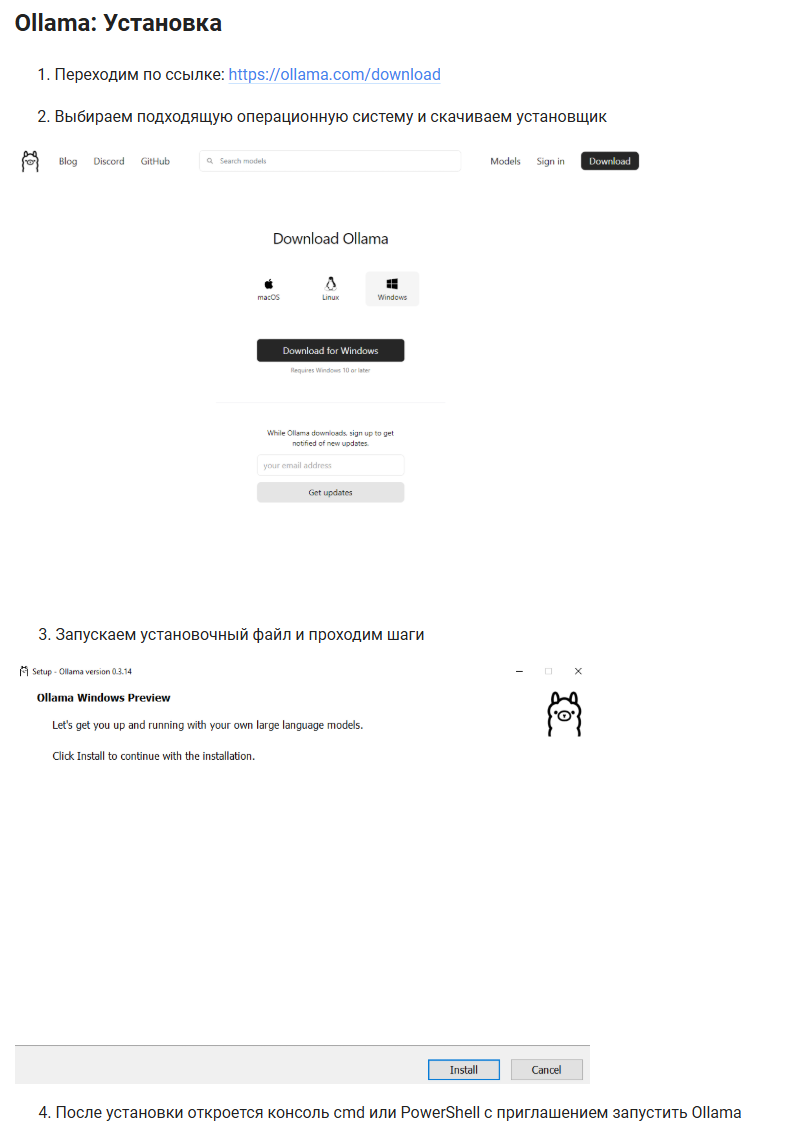

**Ollama: Команды**  
Доступные команды всегда можно посмотреть командой *ollama help*  

**Запустить Ollama**  
*ollama serve*  
В дальнейшем вам придется её использовать после включения компьютера, чтобы воспользоваться Ollama  

**Посмотреть список скаченных моделей**  
В этом списке можно найти информацию о названии модели, размере весов (в гигабайтах) и дате установки.  

*ollama list*  
У вас в начале будет пустым  

**Скачать и запустить конкретную LLM**  
*ollama run tinyllama*  
В данном случае это компактная LLM, у которой всего 1.1 миллиард параметров, она довольно неплохо отвечает, правда, русский не всегда поддерживает.  

Подробнее о модели в её карточке: https://ollama.com/library/tinyllama.  

Больше доступных моделей здесь: https://ollama.com/library  

После скачивания и запуска модели в консоли появится сообщение: “Send a message“, с этого момента мы находимся в режиме чата с LLM. Теперь можно позадавать различные вопросы, история сообщений будет учитываться при ответе.  

В режиме чата тоже есть свои команды, к их полному перечню можно обратиться командой */help*  

Для вставки данных в чат советую нажимать на правую кнопку мыши в консоли, т.к. Ctrl+V у меня не работал  

**Посмотреть запущенные модели**  
*ollama ps*  
Для удобства лучше это делать в отдельной консоли, чтобы не прерывать режим чата в первой консоли и увидеть запущенную модель. Команда отображает информацию о названии модели, идентификаторе запуска, размере на диске, доступе к использованию ресурсов процессора и время запуска модели.  

**Остановить запущенную модель**  
*ollama stop tinyllama*  

**Удалить модель с компьютера**  
*ollama rm tinyllama*  

**Посмотреть информацию о модели без её запуска**  
*ollama show tinyllama*  

**Основные команды в режиме чата**  
**Выйти из режима чата (выключает модель)**  
*/bye*  

**Очистить текущую историю, чтобы она не учитывалась в дальнейших ответах**  
*/clear*  

**Посмотреть информацию о текущей модели: архитектура, число параметров, длина контекста и т.д.**  
*/show info*  

**Иногда бывает полезным посмотреть системное сообщение, которое устанавливает изначальную роль для LLM.**  
*/show system*

# Ollama: Использование API

In [1]:
import json
import requests


OLLAMA_HOST = "localhost"
OLLAMA_PORT = "11434"
SEND_MESSAGE_URL = "api/generate"

URL = f"http://{OLLAMA_HOST}:{OLLAMA_PORT}/{SEND_MESSAGE_URL}"

MODEL_NAME = "llama3.2:3b"
PROMPT = "How are you?"
PARAMETERS = {
    "model": MODEL_NAME,
    "prompt": PROMPT,
    "stream": False,
}

response = requests.post(url = URL, json = PARAMETERS)
data = response.json()
print(json.dumps(data, indent = 4))

{
    "model": "llama3.2:3b",
    "created_at": "2025-05-21T19:00:48.5171967Z",
    "response": "I'm just a language model, so I don't have emotions or feelings like humans do. However, I'm functioning properly and ready to assist you with any questions or tasks you may have! How can I help you today?",
    "done": true,
    "done_reason": "stop",
    "context": [
        128006,
        9125,
        128007,
        271,
        38766,
        1303,
        33025,
        2696,
        25,
        6790,
        220,
        2366,
        18,
        271,
        128009,
        128006,
        882,
        128007,
        271,
        4438,
        527,
        499,
        30,
        128009,
        128006,
        78191,
        128007,
        271,
        40,
        2846,
        1120,
        264,
        4221,
        1646,
        11,
        779,
        358,
        1541,
        956,
        617,
        21958,
        477,
        16024,
        1093,
        12966,
     

# Ollama: Графический интерфейс

В качестве графического интерфейса к Ollama можно использовать Open WebUI  

Ссылка на GitHub проекта: https://github.com/open-webui/open-webui  

Установка и запуск  
Для начала использования графического интерфейса:  

1. Создаем виртуально окружения на Python 3.11
2. Скачиваем библиотеку: pip install open-webui
3. Запускаем сервис: open-webui serve

Предупреждаю, что установка необходимых библиотек может занять какое-то время, так как это целый комбайн по возможностям и интеграциям с разными моделями.

После запуска необходимо зарегистрироваться:

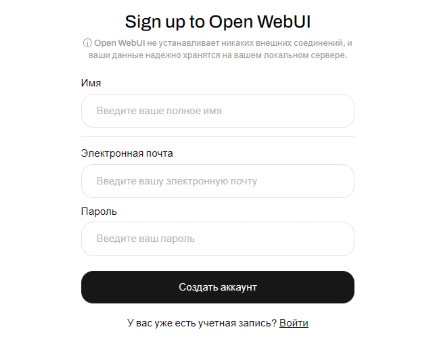

In [ ]:
import requests
import urllib3
import uuid
import httpx

from openai import OpenAI
from dataclasses import dataclass
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)


@dataclass
class Config:
    GIGACHAT_API_PERS = "" # ВАШ ТОКЕН

def get_giga_auth_token(auth_key, scope="GIGACHAT_API_PERS"):
    """Получение токена авторизации GigaChat"""
    URL = "https://ngw.devices.sberbank.ru:9443/api/v2/oauth"
    request_id = str(uuid.uuid4())
    payload = f'scope={scope}'
    headers = {
        'Content-Type': 'application/x-www-form-urlencoded',
        'Accept': 'application/json',
        'RqUID': request_id,
        'Authorization': f'Basic {auth_key}'
    }
    response = requests.request("POST", URL, headers=headers, data=payload, verify=False)
    if response.status_code == 200:
        return response.json()["access_token"]
    else:
        return -1


def send_completition(req, client, model):
    """Отправка запроса в GigaChat"""
    completion = client.chat.completions.create(
        model=model, 
        messages=[
            {"role": "system", "content": "You are a helpful assistant."},
            {"role": "user","content": req}
        ]
    )
    return completion.choices[0].message.content

# Получаем токен авторизация (живет ~30 минут)
auth_token = get_giga_auth_token(
    Config.GIGACHAT_API_PERS,
    "GIGACHAT_API_PERS"
)

# Создаем клиент
client = OpenAI(
    api_key=auth_token,
    base_url="https://gigachat.devices.sberbank.ru/api/v1",
    http_client=httpx.Client(verify=False)
)

# Отправляем запрос
completion = send_completition(
    req="""
    Привет, что ты умеешь?""".strip(),
    client=client,
    model="GigaChat"
)
print(completion)